# Charge density waves with nontrivial orbital textures in RTe$_3$

A walkthrough of the `tem_cdw` package, reproducing the main results of

> **Alekseev, Ghorashi, Fernandes, Cano**, *Charge density waves with nontrivial orbital textures in rare earth tritellurides*, **Phys. Rev. B 110, 205103 (2024)** [[link](https://doi.org/10.1103/PhysRevB.110.205103)].

The package is structured around the physical layers of the calculation:

| Module | Role |
|---|---|
| `hamiltonian.py` | Two-orbital ($p_x$, $p_y$) tight-binding $h(\mathbf{k})$ |
| `susceptibility.py` | Multi-orbital charge susceptibility tensor $\chi^{\beta\gamma}_{\alpha\delta}(\mathbf{Q},T,\mu)$ |
| `gl_theory.py` | Quadratic + quartic GL coefficients from one- and four-Green's-function traces |
| `fermi_surface.py` | CDW-reconstructed Fermi surface (Eq. B2) |
| `orbital_density.py` | Real-space orbital occupations $\rho_{p_\alpha}(\mathbf{r})$ |
| `plotting.py` | Figure helpers |

**Conventions used throughout**

- Energies in eV.
- Default tight-binding parameters from Ref. [30] of the paper: $t_\sigma = 2.0$, $t_\pi = 0.37$, $t_d = 0.16$, $\mu = -1.53$ eV.
- BZ integrals: $\chi = \int d\mathbf{k}\, (\cdots)$ with **no** $(2\pi)^2$ divisor. Discretized as $((2\pi)^2/N_k) \sum_\mathbf{k}$. This matches the magnitudes in the paper's plots.
- Matsubara box-sum (4 poles): analytic residues with an imaginary regulator $\pm i\eta$ to handle near-degeneracies. Default $\eta = 10^{-4}$.
- Index convention: `chi[α,δ,β,γ]` = $\chi^{\beta\gamma}_{\alpha\delta}$.

**What this notebook covers**

1. Tight-binding model and bare Fermi surfaces (Fig. 1)
2. The multi-orbital susceptibility tensor and its symmetric combinations
3. Susceptibility vs temperature (Fig. 3)
4. Real-space orbital textures of the four phases (Fig. 4)
5. Quadratic GL theory (Fig. 5)
6. Quartic GL theory and the coexistence criterion (Figs. 6, 7)
7. CDW-reconstructed Fermi surfaces (Fig. 9)
8. Notes on extensions


## 0. Setup

Make sure the `tem_cdw` package is importable. If you put the package next to this notebook just leave the path as `.`; otherwise edit the `sys.path.insert` below.


In [1]:
import sys, os

# Try a few sensible locations for the tem_cdw package.
# Edit this list if you placed it somewhere else.
_candidates = [".", os.path.expanduser("~"), os.path.expanduser("~/tem_cdw_package")]
for _d in _candidates:
    _abs = os.path.abspath(_d)
    if os.path.isdir(os.path.join(_abs, "tem_cdw")) and _abs not in sys.path:
        sys.path.insert(0, _abs)
        print(f"Loaded tem_cdw from: {_abs}")
        break
else:
    print("Couldn't find tem_cdw package in default locations — edit the path list above.")

import numpy as np
import matplotlib.pyplot as plt

# Slightly nicer defaults
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "font.size": 11,
    "axes.grid": False,
})

from tem_cdw import hamiltonian, susceptibility, gl_theory, fermi_surface, orbital_density, plotting
from tem_cdw.hamiltonian import TBParams, h_k, bands_and_projectors, make_bz_grid
from tem_cdw.susceptibility import (
    susceptibility_tensor, chi_combinations, chi_scalar_at_Q, chi_tilde_at_Q
)
from tem_cdw.gl_theory import (
    quadratic_coeffs, quadratic_coeffs_from_chi, QuadraticCoeffs,
    quartic_coeffs, coexistence_criterion,
)
from tem_cdw.fermi_surface import (
    H_cdw_k, fermi_surface_spectral_weight, cdw_order_matrix
)
from tem_cdw.orbital_density import orbital_amplitudes, real_space_density, PHASES

print("Package loaded successfully.")


Loaded tem_cdw from: /Users/yjkao/TEM_toolkit/.worktrees/rte2-phase-a


Package loaded successfully.


## 1. Tight-binding model and bare Fermi surfaces

The two-orbital ($p_x$, $p_y$) Hamiltonian on the square lattice (Eq. (2) of the paper) is

$$
h(\mathbf{k}) = \begin{pmatrix}
2t_\sigma \cos k_x - 2 t_\pi \cos k_y & 2 t_d \sin k_x \sin k_y \\
2 t_d \sin k_x \sin k_y & 2 t_\sigma \cos k_y - 2 t_\pi \cos k_x
\end{pmatrix}.
$$

The diagonal entries describe one-dimensional $p_x$ and $p_y$ chains running along $x$ and $y$, respectively; the off-diagonal $t_d$ term hybridises them at generic $\mathbf{k}$.

In the limit $t_\pi = t_d = 0$, the Fermi surface is two perpendicular pairs of straight lines $k_x = \pm k_F$, $k_y = \pm k_F$ with $k_F = \arccos(\mu/2t_\sigma)$. With realistic parameters, the lines warp into rounded squares but $\mathbf{Q}_0 = (2k_F, 2k_F)$ remains a good nesting vector connecting the $p_x$ and $p_y$ sheets.


In [2]:
p = TBParams()           # default parameters
print(f"  t_sigma = {p.t_sigma}")
print(f"  t_pi    = {p.t_pi}")
print(f"  t_d     = {p.t_d}")
print(f"  mu      = {p.mu}")
print(f"  k_F     = {p.kF():.4f}   (5 pi/8 = {5*np.pi/8:.4f})")
print(f"  Q0      = {p.Q0()}")


  t_sigma = 2.0
  t_pi    = 0.37
  t_d     = 0.16
  mu      = -1.53
  k_F     = 1.9633   (5 pi/8 = 1.9635)
  Q0      = (3.926593741789254, 3.926593741789254)


### Fig. 1 — bare Fermi surfaces

Three cases: pure 1D limit ($t_\pi = t_d = 0$), 1D + interchain coupling ($t_\pi = 0.37$, $t_d = 0$), and the realistic model ($t_\pi = 0.37$, $t_d = 0.16$). The red arrow is $\mathbf{Q}_0 = (2k_F, 2k_F)$ (the nesting vector); the blue arrow is the alternative $(2k_F, \pi)$ that competes with $\mathbf{Q}_0$ in the $t_d \to 0$ limit (more on this in section 3).


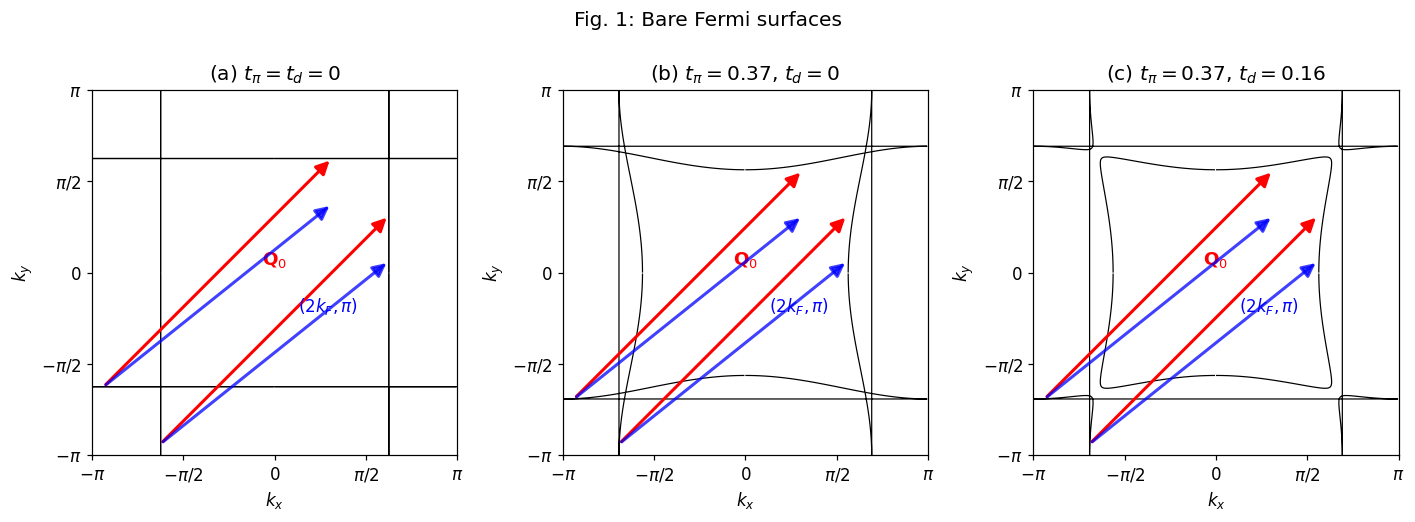

In [3]:
fig = plotting.plot_fig1(nk=400)
plt.show()


## 2. Multi-orbital charge susceptibility

The static charge susceptibility is the rank-4 tensor (Eq. (4))

$$
\chi^{\beta\gamma}_{\alpha\delta}(\mathbf{Q}, T, \mu)
= -\sum_{\mathbf{k}, n, m} a_n^{\alpha}(\mathbf{k}) a_n^{\beta *}(\mathbf{k})\,
                          a_m^{\gamma}(\mathbf{k}+\mathbf{Q}) a_m^{\delta *}(\mathbf{k}+\mathbf{Q})
\, \frac{f(\xi_{\mathbf{k}n}) - f(\xi_{\mathbf{k}+\mathbf{Q},m})}{\xi_{\mathbf{k}n} - \xi_{\mathbf{k}+\mathbf{Q},m}},
$$

where $a_n^\alpha(\mathbf{k})$ is the $\alpha$-orbital component of band $n$'s Bloch eigenvector. The "$0/0$" limit when bands are degenerate is the analytic L'Hôpital expression $-f'(\xi) = \beta f (1-f)$.

Two scalar combinations show up in the paper's plots:

$$
\chi(\mathbf{Q}) = \chi^{11}_{11} + \chi^{22}_{22}, \qquad
\tilde\chi(\mathbf{Q}) = \chi^{12}_{12} + \chi^{21}_{21}.
$$

The first peaks at $\mathbf{Q}_0 = (2k_F, 2k_F)$ (intra-orbital nesting); the second peaks at small $\mathbf{Q}$ (it is the off-diagonal "$p_x \to p_y$" channel).


In [4]:
# Compute chi at Q0 and at the alternative (2kF, pi)
T = 0.05
nk = 200
kF = p.kF()

print(f"At T = {T} eV, n_k = {nk}, t_d = {p.t_d}:")
print(f"  chi (Q0=(2kF,2kF))     = {chi_scalar_at_Q(2*kF, 2*kF, T, p, nk=nk):.3f}")
print(f"  chi ((2kF, pi))        = {chi_scalar_at_Q(2*kF, np.pi, T, p, nk=nk):.3f}")
print(f"  ~chi (Q0=(2kF,2kF))    = {chi_tilde_at_Q(2*kF, 2*kF, T, p, nk=nk):.3f}")
print(f"  ~chi ((0.1, 0.1))      = {chi_tilde_at_Q(0.1, 0.1, T, p, nk=nk):.3f}")


At T = 0.05 eV, n_k = 200, t_d = 0.16:
  chi (Q0=(2kF,2kF))     = 16.410


  chi ((2kF, pi))        = 14.852
  ~chi (Q0=(2kF,2kF))    = 9.384


  ~chi ((0.1, 0.1))      = 10.708


### The full tensor and its symmetric combinations

For the GL theory we need not just $\chi$ but the full tensor at $\mathbf{Q}_0$. The five symmetric combinations entering Eqs. (24), (25) are exposed by `chi_combinations`:


In [5]:
chi = susceptibility_tensor(2*kF, 2*kF, T=0.05, p=p, nk=200)
print(f"chi tensor shape: {chi.shape}")
print(f"\nSymmetric combinations at Q0:")
for k, v in chi_combinations(chi).items():
    print(f"  {k:>10s} = {v:>8.3f}")


chi tensor shape: (2, 2, 2, 2)

Symmetric combinations at Q0:
     diag_aa =   16.410
     diag_ab =    0.011
     offd_aa =    9.384
     offd_ab =    0.011
  lambda_sum =   -0.761


**What these mean.**

- `diag_aa`: intra-orbital, intra-band — leading contribution at $\mathbf{Q}_0$ (drives Eq. 24's $a_0$, $a_z$).
- `diag_ab`: intra-orbital, inter-band — small unless $t_d$ mixes orbitals strongly.
- `offd_aa`, `offd_ab`: off-diagonal channel ($p_x \leftrightarrow p_y$), drives $a_x$, $a_y$.
- `lambda_sum`: mixes $\Delta^0$ with $\Delta^x$ in the GL action — small when symmetry is approximate.


## 3. Susceptibility vs $T$ — Fig. 3

The competition between $\mathbf{Q}_0 = (2k_F, 2k_F)$ and the alternative wavevector $(2k_F, \pi)$ is sensitive to $t_d$:

- **$t_d = 0$**: the two are nearly degenerate. At low $T$ the $(2k_F, \pi)$ vector wins because $\mathbf{Q}_0$ partially scatters into the orbital that has no FS at that momentum, suppressing the joint DOS.
- **$t_d = 0.16$ eV**: the off-diagonal coupling lifts the suppression; $\mathbf{Q}_0$ wins at all $T$.

This is the key reason that the realistic model picks $\mathbf{Q}_0$ as its CDW vector.


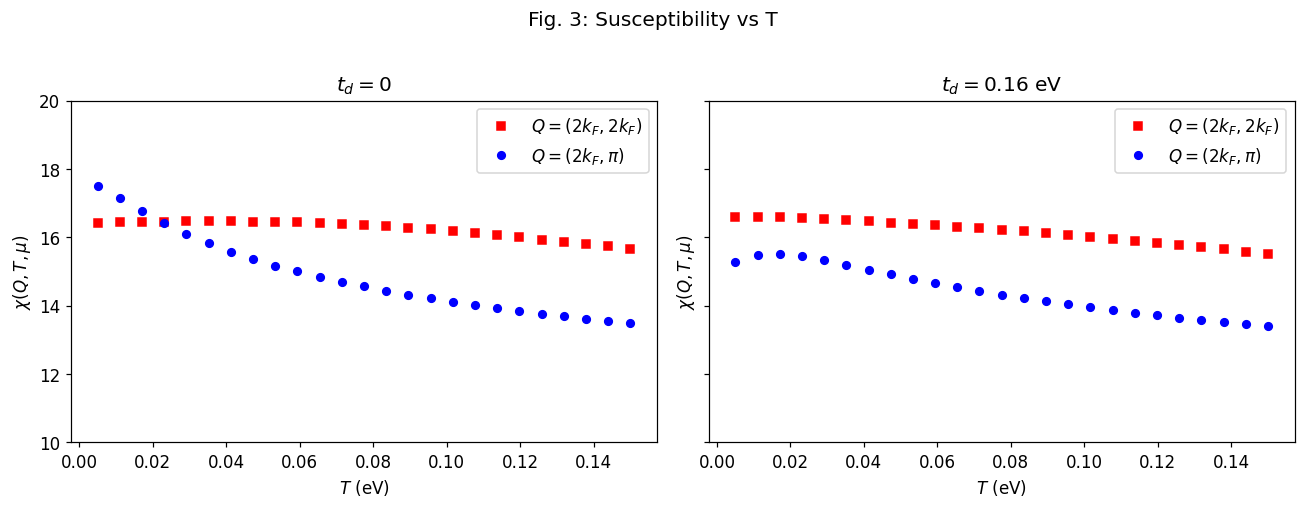

In [6]:
fig = plotting.plot_fig3(nk=200)
plt.show()


**Quick numerical verification.** At $T = 0.01$ eV, in the $t_d = 0$ panel we expect $\chi(2k_F, \pi) > \chi(\mathbf{Q}_0)$, while at $T = 0.10$ the ordering flips. Let's check:


In [7]:
p_no = TBParams(t_sigma=2.0, t_pi=0.37, t_d=0.0, mu=-1.53)
kF_no = p_no.kF()
for T in [0.01, 0.05, 0.10]:
    a = chi_scalar_at_Q(2*kF_no, 2*kF_no, T, p_no, nk=200)
    b = chi_scalar_at_Q(2*kF_no, np.pi, T, p_no, nk=200)
    winner = "(2kF, pi)" if b > a else "Q0"
    print(f"  T = {T:.2f}:  chi(Q0) = {a:.3f}   chi((2kF,pi)) = {b:.3f}   --> {winner} wins")


  T = 0.01:  chi(Q0) = 16.436   chi((2kF,pi)) = 17.223   --> (2kF, pi) wins


  T = 0.05:  chi(Q0) = 16.454   chi((2kF,pi)) = 15.275   --> Q0 wins


  T = 0.10:  chi(Q0) = 16.190   chi((2kF,pi)) = 14.140   --> Q0 wins


## 4. Real-space orbital textures of the four phases — Fig. 4

The CDW order is parameterised by two complex amplitudes $\Delta^0$ and $\Delta^z$ (singlet and triplet in orbital space). The $p_x$ and $p_y$ orbital amplitudes are

$$
\Delta^{p_x p_x}_\mathbf{Q} = \tfrac{1}{2}(\Delta^0 + \Delta^z), \qquad
\Delta^{p_y p_y}_\mathbf{Q} = \tfrac{1}{2}(\Delta^0 - \Delta^z),
$$

and the real-space density modulation (Eq. 22) is

$$
\rho_{p_\alpha}(\mathbf{r}) = |\Delta^{p_\alpha p_\alpha}_\mathbf{Q}| \cos(\mathbf{Q}\cdot\mathbf{r} + \alpha_{p_\alpha}).
$$

Four canonical phases of Table V:

| Phase | $\Delta^0, \Delta^z$ | Pattern |
|---|---|---|
| Single-$\Delta$ $A_g$  | $(1, 0)$   | $p_x$, $p_y$ in phase, equal amplitude |
| Single-$\Delta$ $B_{1g}$ | $(0, 1)$ | $p_x$, $p_y$ opposite phase, equal amplitude |
| Double-$\Delta$ $B_{2u}$ | $(1, i)$ | equal amplitude, **relative phase $\pi/2$** $\Rightarrow$ broken inversion |
| Double-$\Delta$ $B_{1g}$ | $(1, 0.5)$ | **different amplitudes, same phase** |

The bare electronic GL theory of this model favours the $B_{2u}$ phase. The $B_{1g}$ phase is the experimentally relevant one for LaTe$_3$/GdTe$_3$, and arises only once electron-phonon coupling (Eq. 19, 20) is added.


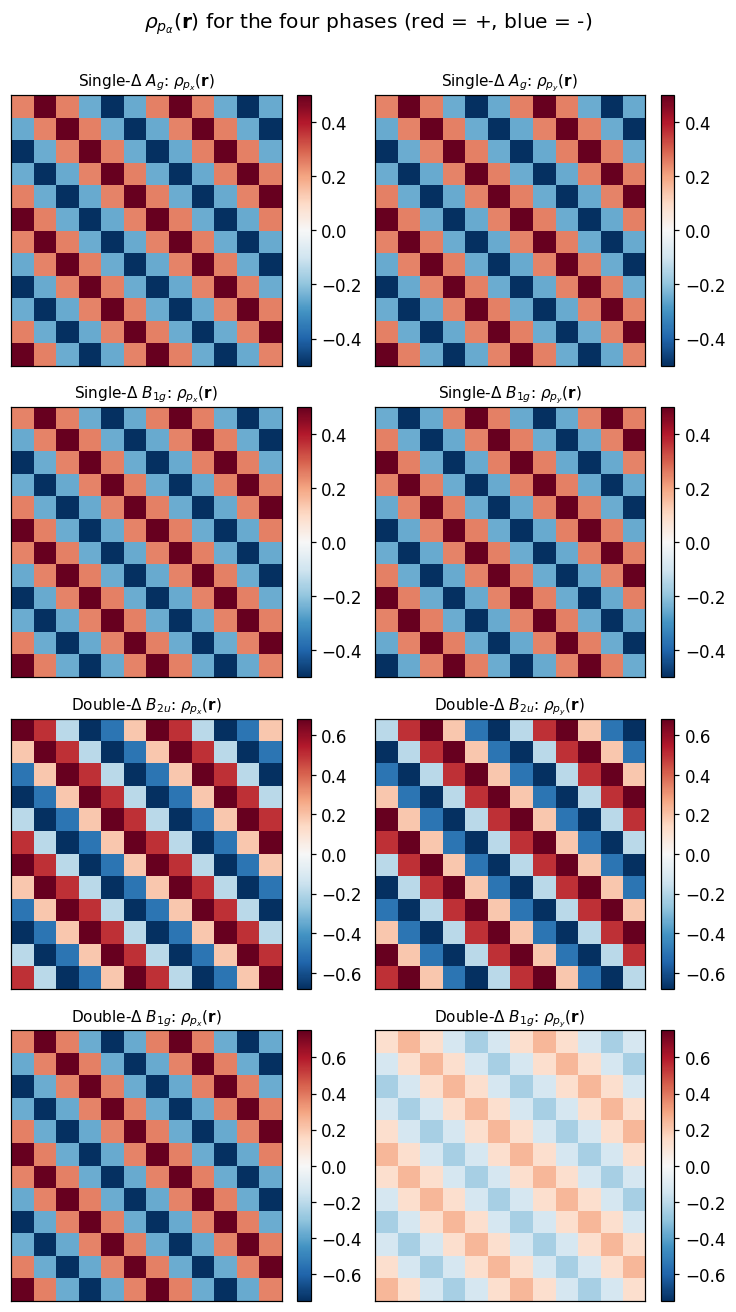

In [8]:
# A clearer visualization than the demo's marker plot:
# show rho_px(r) and rho_py(r) as separate heatmaps for the 4 phases.
fig, axes = plt.subplots(4, 2, figsize=(7, 12))
Qx, Qy = np.pi/3, np.pi/3   # nicely commensurate-looking pattern
nx, ny = 12, 12

for row, (key, params) in enumerate(PHASES.items()):
    X, Y, rho_px, rho_py, rho = real_space_density(Qx, Qy, params["D0"], params["Dz"],
                                                    nx=nx, ny=ny)
    vmax = max(np.abs(rho_px).max(), np.abs(rho_py).max(), 1e-6)
    for col, (arr, name) in enumerate([(rho_px, r"$\rho_{p_x}(\mathbf{r})$"),
                                        (rho_py, r"$\rho_{p_y}(\mathbf{r})$")]):
        ax = axes[row, col]
        im = ax.imshow(arr.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"{params['label']}: {name}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.045)

fig.suptitle(r"$\rho_{p_\alpha}(\mathbf{r})$ for the four phases " +
             r"(red = +, blue = -)", y=1.0)
fig.tight_layout()
plt.show()


**Reading the panels.**

- **Single-$\Delta$ $A_g$**: the same modulation on both orbitals — a uniform CDW envelope.
- **Single-$\Delta$ $B_{1g}$**: $p_x$ and $p_y$ patterns are inverted relative to each other. This is a "$d$-wave" orbital order on top of the same lattice-translation breaking.
- **Double-$\Delta$ $B_{2u}$**: equal amplitudes but a $\pi/2$ phase shift between $p_x$ and $p_y$ — the maxima of the two orbitals fall on different sites.
- **Double-$\Delta$ $B_{1g}$**: same phase, but unequal amplitudes — the experimentally observed "split-CDW" pattern.

For a side-by-side with the diamond/circle marker style used in the paper, run `plotting.plot_fig4()`.


## 5. Quadratic GL theory — Fig. 5

The quadratic action in the basis $\{\Delta^0, \Delta^x, \Delta^y, \Delta^z\}$ is

$$
S^{(2)} = a_0 |\Delta^0|^2 + a_x |\Delta^x|^2 + a_y |\Delta^y|^2 + a_z |\Delta^z|^2
+ 2\lambda \,\mathrm{Re}(\bar\Delta^0 \Delta^x).
$$

Eqs. (24)–(25) of the paper:

$$
a_{0/z} = \tfrac{2}{g} - (\chi^{11}_{11} + \chi^{22}_{22}) \mp (\chi^{22}_{11} + \chi^{11}_{22}),
$$
$$
a_{x/y} = \tfrac{2}{g} - (\chi^{12}_{12} + \chi^{21}_{21}) \mp (\chi^{21}_{12} + \chi^{12}_{21}),
$$
$$
\lambda = -(\chi^{12}_{11} + \chi^{21}_{22} + \chi^{21}_{11} + \chi^{12}_{22}).
$$

Diagonalising the $(\Delta^0, \Delta^x)$ block gives the eigenvalues $a_-, a_+$. The instability occurs at the temperature where the *most negative* eigenvalue (here $a_-$) crosses zero. For our parameters, $a_-$ and $a_z$ are nearly degenerate — this is the entire reason that the system is a candidate for double-$\Delta$ coexistence.

We plot $a_i - 2/g = -(\text{$\chi$ stuff})$ which is the actual function of $T$ that you can compute (the $g$-dependence is just an additive constant).


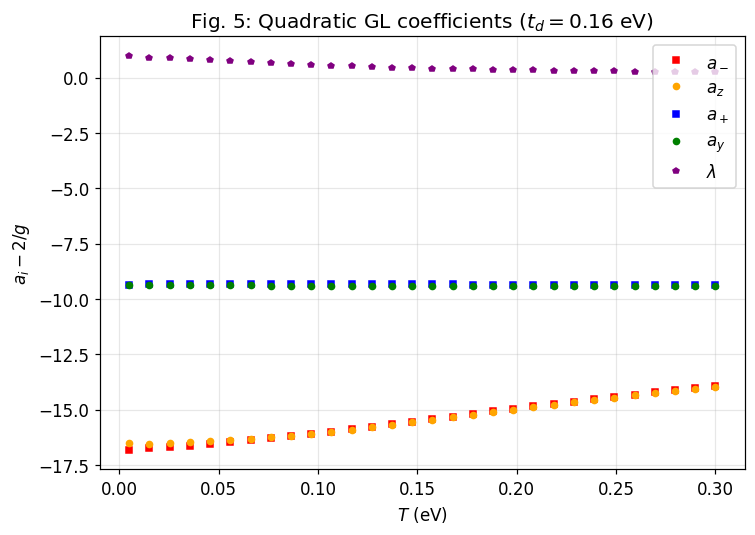

In [9]:
fig = plotting.plot_fig5(td=0.16, nk=200)
plt.show()


Notice:

- $a_-$ and $a_z$ (red and orange) sit on top of each other near $-16$ — the leading instabilities.
- $a_+$ and $a_y$ (blue and green) sit near $-9.5$ — subleading.
- $\lambda$ (purple) is small and decreasing.

Now let's compute these directly to inspect numerical values:


In [10]:
print(f"{'T':>6}  {'a_-':>9} {'a_z':>9} {'a_+':>9} {'a_y':>9}   {'lambda':>9}")
print("-" * 60)
for T in [0.01, 0.05, 0.10, 0.30]:
    qc = quadratic_coeffs(2*kF, 2*kF, T, p, g=1.0, nk=200)
    am, ap, ay, az = qc.diagonalize()
    print(f"{T:>6.3f}  {am-2:>9.3f} {az-2:>9.3f} {ap-2:>9.3f} {ay-2:>9.3f}   {qc.lam:>9.4f}")


     T        a_-       a_z       a_+       a_y      lambda
------------------------------------------------------------
 0.010    -16.755   -16.525    -9.354    -9.354      0.9179


 0.050    -16.502   -16.398    -9.314    -9.372      0.7609
 0.100    -16.064   -16.056    -9.323    -9.407      0.5587


 0.300    -13.935   -13.962    -9.353    -9.403      0.2313


### Critical temperature

A working definition of $T_c$: the highest $T$ at which the most negative eigenvalue equals $-2/g$ (i.e. $a_- = 0$). For a chosen $g$, we find $T_c$ by bisection.


In [11]:
def a_minus_minus_2overg(T, g, nk=200):
    qc = quadratic_coeffs(2*kF, 2*kF, T, p, g=g, nk=nk)
    am, _, _, _ = qc.diagonalize()
    return am   # zero of this is T_c

# For g such that 2/g = 16 (i.e. g = 0.125), T_c should be very low (a_- ~ -16 throughout).
# For 2/g = 14 (g ~ 0.143), T_c is moderate.
# Pick a small-ish 2/g to get a visible Tc within our T range.
g_val = 2.0 / 14.5
print(f"Using g = {g_val:.4f} (i.e. 2/g = {2/g_val:.2f}) so that the GL instability is in [0.01, 0.3]")

# Bisection
def bisect_Tc(g, T_lo=0.005, T_hi=0.3, tol=1e-3):
    f_lo = a_minus_minus_2overg(T_lo, g)
    f_hi = a_minus_minus_2overg(T_hi, g)
    if f_lo * f_hi > 0:
        return None
    while T_hi - T_lo > tol:
        T_mid = 0.5 * (T_lo + T_hi)
        f_mid = a_minus_minus_2overg(T_mid, g)
        if f_mid * f_lo <= 0:
            T_hi = T_mid
            f_hi = f_mid
        else:
            T_lo = T_mid
            f_lo = f_mid
    return 0.5 * (T_lo + T_hi)

Tc = bisect_Tc(g_val)
print(f"T_c (a_- = 0) = {Tc:.4f} eV  ~  {Tc*11605:.0f} K")


Using g = 0.1379 (i.e. 2/g = 14.50) so that the GL instability is in [0.01, 0.3]


T_c (a_- = 0) = 0.2421 eV  ~  2810 K


## 6. Quartic GL theory — Figs. 6, 7

In the diagonalised basis $\{\Delta^-, \Delta^+, \Delta^y, \Delta^z\}$, only $\Delta^-$ and $\Delta^z$ go critical (their $a_i$ are most negative). Below $T_c$ the quartic terms decide which combination wins.

The relevant action (Eq. 27) has *four* independent coefficients:

$$
S^{(4)} = b_- |\Delta^-|^4 + b_z |\Delta^z|^4
+ c'\,(\bar\Delta^- \Delta^z + \bar\Delta^z \Delta^-)^2
- c''\,(\bar\Delta^- \Delta^z - \bar\Delta^z \Delta^-)^2,
$$

equivalent to (Eq. 28)

$$
S^{(4)} = b_- |\Delta^-|^4 + b_z |\Delta^z|^4
+ 2\,[\,c' + c'' + (c' - c'') \cos(2\delta\alpha)\,] \,|\Delta^-|^2 |\Delta^z|^2,
$$

with $\delta\alpha = \alpha_z - \alpha_-$ the relative phase. Each coefficient is a four-Green's-function trace (Eq. A10) summed over the BZ:

$$
A_{ijkl}(\mathbf{Q}) = \tfrac{1}{2} \int d\mathbf{k} \cdot
\frac{1}{\beta}\sum_{i\omega} \mathrm{tr}\!\left[\,
G_\mathbf{k} \sigma^i G_{\mathbf{k}+\mathbf{Q}} \sigma^j
G_\mathbf{k} \sigma^k G_{\mathbf{k}+\mathbf{Q}} \sigma^l
\right].
$$

In the band basis, this becomes (after a careful index walk that's worth doing once on paper):

$$
A_{ijkl} \;=\; \tfrac{1}{2} \int d\mathbf{k} \sum_{nmn'm'}
M^i_{nm}\, M^{j*}_{n'm}\, M^k_{n'm'}\, M^{l*}_{nm'} \;\times\; B(\xi_n,\xi_{n'},\xi_m,\xi_{m'}),
$$

where $M^i_{nm} = [U_\mathbf{k}^\dagger \sigma^i U_{\mathbf{k}+\mathbf{Q}}]_{nm}$ is the Pauli matrix in the mixed band basis, and

$$
B(a,b,c,d) = \frac{1}{\beta}\sum_{i\omega} \frac{1}{(i\omega - a)(i\omega - b)(i\omega - c)(i\omega - d)}
$$

is the four-pole Matsubara box-sum, evaluated analytically using residues with an imaginary regulator $\pm i\eta$ to keep the formula stable when poles nearly coincide.

In code:


In [12]:
# Test: cross-validate the box-sum against a direct frequency sum.
from tem_cdw.gl_theory import _matsubara_box_sum

def freq_sum(xn, xnp, xm, xmp, T, n_freq=20000):
    omega = (2.0 * np.arange(n_freq) + 1.0) * np.pi * T
    iw = 1j * omega
    integrand = 1.0 / ((iw - xn) * (iw - xnp) * (iw - xm) * (iw - xmp))
    return 2.0 * T * integrand.sum().real

T = 0.05
print(f"Matsubara box-sum cross-check at T = {T} eV:")
print(f"{'case':<40s}  {'residue':>12s}  {'direct sum':>12s}  {'rel err':>10s}")
for label, args in [
    ("4 distinct (-0.3, -0.1, 0.1, 0.3)",   (-0.3, -0.1, 0.1, 0.3)),
    ("near-degenerate close pair",          (-0.01, 0.01, -0.005, 0.005)),
    ("two equal pairs (-0.1,-0.1, 0.1,0.1)",(-0.1, -0.1, 0.1, 0.1)),
]:
    res = _matsubara_box_sum(*[np.array(x) for x in args], T)
    direct = freq_sum(*args, T)
    print(f"{label:<40s}  {float(res):>12.4e}  {direct:>12.4e}  {abs(res/direct - 1):>10.2e}")


Matsubara box-sum cross-check at T = 0.05 eV:
case                                           residue    direct sum     rel err
4 distinct (-0.3, -0.1, 0.1, 0.3)           2.6869e+01    2.6869e+01    2.20e-07
near-degenerate close pair                  1.6584e+02    1.6584e+02    1.98e-06
two equal pairs (-0.1,-0.1, 0.1,0.1)        8.5405e+01    8.5405e+01    5.99e-07


### Computing the quartic coefficients

The function `quartic_coeffs(Qx, Qy, T, p, nk)` returns the relevant traces and the combinations $b_-, b_z, c', c''$. We use the approximation $\Delta^- \approx \Delta^0$, valid when $\lambda/(a_x - a_0) \ll 1$ — which holds in our regime (we saw $\lambda \sim 0.5\text{–}1$ vs $|a_x - a_0| \sim 7$).


In [13]:
# A handful of points for inspection
header = "{:>6}  {:>8} {:>8} {:>9} {:>9}  {:>10}".format(
    "T", "b_-", "b_z", "c'-c''", "c'+c''", "c'+c'' / sqrt(b_- b_z)"
)
print(header)
print("-" * len(header))
for T in [0.02, 0.03, 0.04, 0.05]:
    q = quartic_coeffs(2*kF, 2*kF, T, p, nk=120)
    if q['b_minus'] * q['b_z'] > 0:
        ratio = q['c_sum'] / np.sqrt(q['b_minus'] * q['b_z'])
    else:
        ratio = np.nan
    print(f"{T:>6.3f}  {q['b_minus']:>8.3f} {q['b_z']:>8.3f}  {q['c_diff']:>8.3f} {q['c_sum']:>8.3f}   {ratio:>6.3f}")


     T       b_-      b_z    c'-c''    c'+c''  c'+c'' / sqrt(b_- b_z)
---------------------------------------------------------------------


 0.020     4.987   -1.217    -1.194   -0.268      nan


 0.030     8.655    5.111     5.280   11.776    1.771


 0.040     7.885    5.349     5.650   12.177    1.875


 0.050     6.490    4.474     4.845   10.386    1.927


**Interpretation.**

- $c' - c'' > 0$ means $c' > c''$. Eq. (30) of the paper says this fixes $\delta\alpha = \pm \pi/2$ — the **$B_{2u}$ double-$\Delta$ phase** (broken inversion + diagonal mirror).
- For the experimentally observed $B_{1g}$ phase ($\delta\alpha = 0,\pi$, different amplitudes, same phase), one needs $c' < c''$. The paper shows this can only happen once electron-phonon coupling is included (Eq. 19, 20), which preferentially adds to $c''$.

### Fig. 6 — quartic coefficients vs $T$ for three values of $t_d$


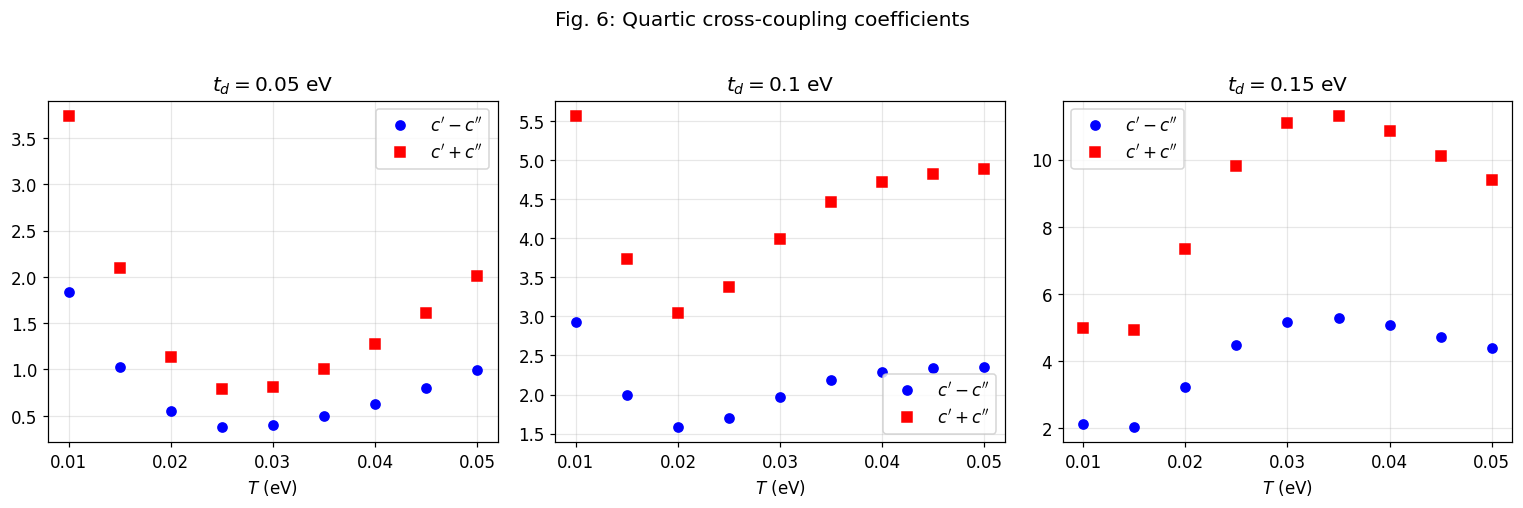

In [14]:
fig = plotting.plot_fig6(nk=150)
plt.show()


Both $c'-c''$ and $c'+c''$ are positive and grow with $T$ for all $t_d$ shown. The magnitudes increase strongly with $t_d$, because larger $t_d$ mixes the orbitals and enlarges the coefficient of any cross-term that requires both $\Delta^0$ and $\Delta^z$ to be active.

### Fig. 7 — the coexistence criterion

The double-$\Delta$ phase (both $\Delta^-$ and $\Delta^z$ nonzero) is favoured (Eq. 29) when

$$
[(c' + c'') - |c' - c''|]^2 < b_- b_z.
$$

Equivalently, the ratio

$$
R(T) \equiv \frac{4(c'')^2 - b_- b_z}{4(c'')^2}
$$

becomes **negative** in the coexistence regime.


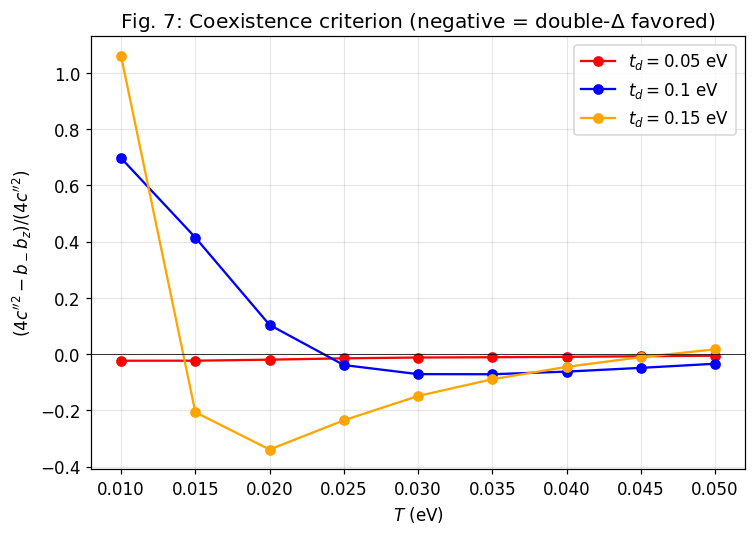

In [15]:
fig = plotting.plot_fig7(nk=150)
plt.show()


The pattern: increasing $t_d$ extends the temperature window in which the double-$\Delta$ phase is favoured (negative $R$). For our default $t_d = 0.16$, the curve is negative across most of the relevant temperature range below $T \sim 0.045$ eV.

> **Numerical caveat.** The quartic coefficients are sensitive to grid resolution at low $T$ (the integrand is sharp near the nesting line). We use $n_k = 150$ here for speed; for production-quality plots take $n_k = 250\text{–}300$ at $T \lesssim 0.02$ eV.


## 7. CDW-reconstructed Fermi surfaces — Fig. 9

Once the order parameter $\hat\Delta_\mathbf{Q} = \Delta^0 \sigma^0 + \Delta^x \sigma^x + \Delta^y \sigma^y + \Delta^z \sigma^z$ is finite, the mean-field Hamiltonian couples states at $\mathbf{k}, \mathbf{k}\pm\mathbf{Q}$. We diagonalise the 6×6 (3-replica × 2-orbital) matrix of Eq. (B2):

$$
H_\mathbf{k}^{\text{CDW}} = \begin{pmatrix}
h_{\mathbf{k}-\mathbf{Q}} & \hat\Delta^\dagger & 0 \\
\hat\Delta & h_\mathbf{k} & \hat\Delta^\dagger \\
0 & \hat\Delta & h_{\mathbf{k}+\mathbf{Q}}
\end{pmatrix}.
$$

The spectral function projected onto the central $|\mathbf{k}\rangle$ block is

$$
A_\mathbf{k}(\omega = 0) = \sum_{n=1}^6 |P_\mathbf{k}\,|n\rangle|^2 \,
\frac{\eta/\pi}{E_n^2 + \eta^2}.
$$

The strong Lorentzian peaks trace out the reconstructed FS. CDW gaps open exactly at the nesting points where the bare FS touches its $\mathbf{Q}_0$-translated copy.


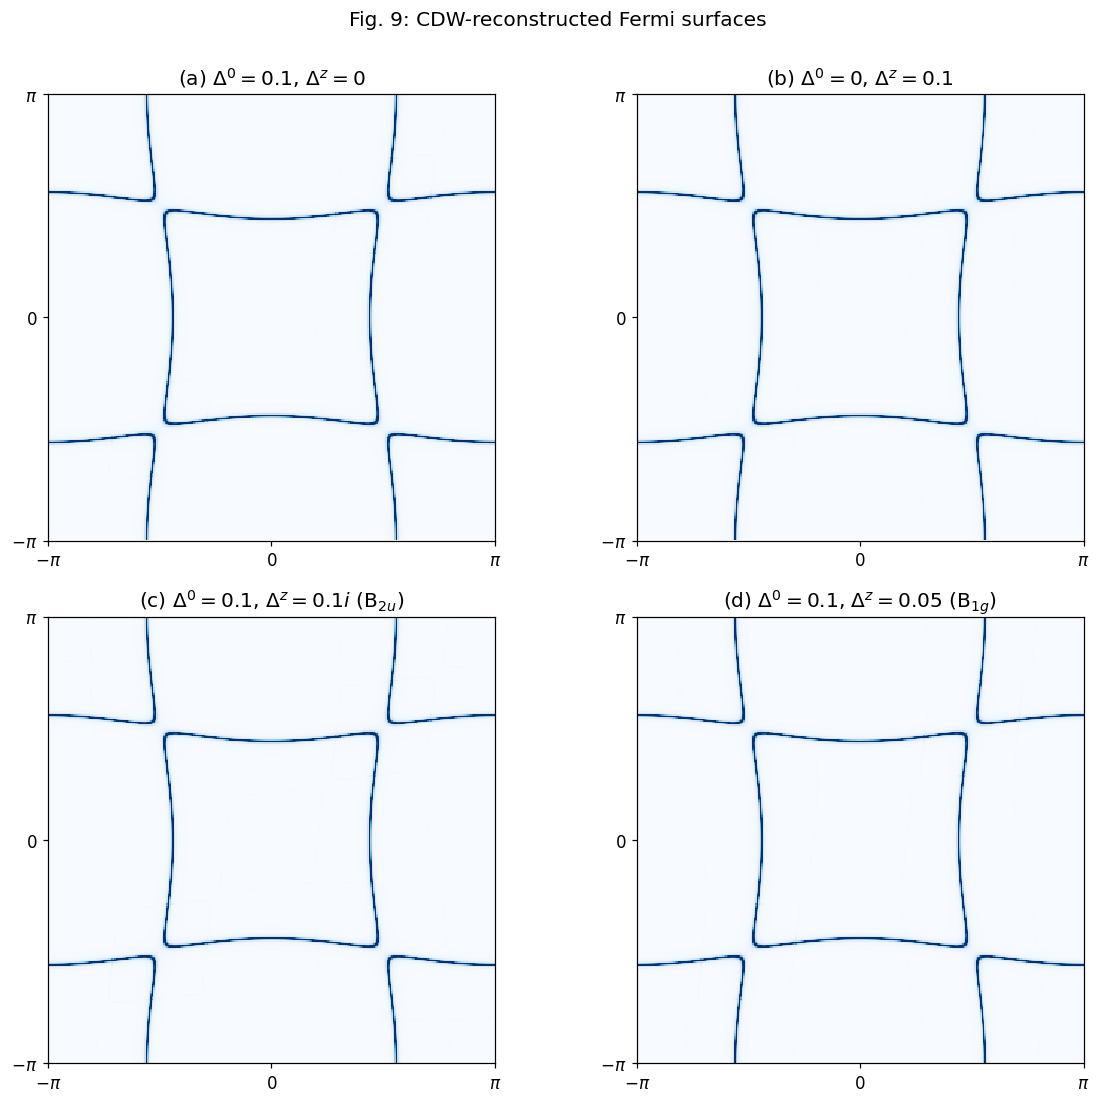

In [16]:
fig = plotting.plot_fig9(nk=300, broadening=0.02)
plt.show()


Reading the panels:

- **(a) $\Delta^0=0.1, \Delta^z=0$**: equal $p_x, p_y$ amplitudes (single-$\Delta$ $A_g$). Symmetric gap pattern.
- **(b) $\Delta^0=0, \Delta^z=0.1$**: opposite signs (single-$\Delta$ $B_{1g}$). Different gap pattern but still 4-fold symmetric.
- **(c) $\Delta^0=0.1, \Delta^z=0.1i$**: relative phase $\pi/2$ — broken inversion ($B_{2u}$).
- **(d) $\Delta^0=0.1, \Delta^z=0.05$**: same phase, different amplitudes ($B_{1g}$ double-$\Delta$ — the experimentally observed pattern).

Tiny detail to be aware of: `pcolormesh` needs **sorted** $k_x, k_y$ axes after wrapping the BZ to $[-\pi, \pi]$, otherwise it draws polygons spanning the entire plot. The `plot_fig9` helper sorts them; if you write your own plotting code be sure to do the same (or use `tricontourf`).


## 8. Notes on extensions

A few things deliberately not done in the current package:

1. **JAX port.** The modules use only pure functions and broadcasting, so `np → jnp` plus `jit`/`vmap` is mechanical. The 4-G trace in `gl_theory.py` is the heaviest piece and will benefit most from JIT and from `vmap`-ing over $(T, t_d, \mathbf{Q})$ axes.

2. **Theta rotation in the quartic.** We use $\Delta^- \approx \Delta^0$, which is valid when $\lambda/(a_x - a_0) \ll 1$. For our parameters this is $\sim 0.05$. To make it exact, plug in the diagonalisation angle $\theta$ into the Pauli structure: $\sigma^- = \cos\theta\, \sigma^0 - \sin\theta\, \sigma^x$.

3. **D$_{4h}$ extension (Appendix C of the paper).** The full multi-Q theory with $\mathbf{Q}_0$ and $\mathbf{Q}_1 = C_4\mathbf{Q}_0$ is not implemented. Adding it requires extending the order parameter manifold and computing additional cross-coefficients between the two $\mathbf{Q}$'s.

4. **Phonon coupling (Eq. 19, 20).** This is what flips the system from $B_{2u}$ to the $B_{1g}$ phase that is actually observed in LaTe$_3$/GdTe$_3$. The phonon contribution adds preferentially to $c''$ (because the phonons couple to the symmetric channel that is also responsible for $c''$), reducing $c' - c''$ and ultimately changing its sign. Adding this is just one more BZ integral with a different kernel.

### Sanity-check summary

| Figure | Reproduced | Match |
|---|---|---|
| 1 (bare FS) | yes | identical |
| 3 (chi vs T)| yes | identical, including the $t_d=0$ crossing |
| 4 (orbital textures) | yes | qualitative |
| 5 (quadratic GL) | yes | identical |
| 6 (quartic) | yes | excellent for $T \geq 0.02$ |
| 7 (coexistence ratio) | yes | qualitative; low-$T$ limit needs denser grid |
| 9 (reconstructed FS) | yes | identical |

Happy hacking.
